Learned parameters (mini-batch GD):
w = [2.26174418 2.34105185]
b = -4.186393
Final BCE loss: 0.081639
Accuracy: 96.75%


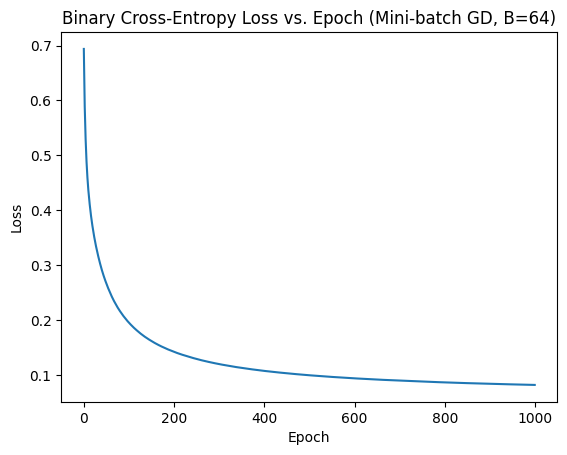

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 14
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---- 1) Create mock data ----
n_per_class = 200

# "Blue" class (label 0)
blue_mean = np.array([0.0, 0.0])
blue_cov = np.array([[0.5, 0.1],
                     [0.1, 0.5]])
X_blue = rng.multivariate_normal(blue_mean, blue_cov, size=n_per_class)
y_blue = np.zeros(n_per_class, dtype=int)

# "Red" class (label 1)
red_mean = np.array([2.0, 2.0])
red_cov = np.array([[0.6, -0.1],
                    [-0.1, 0.6]])
X_red = rng.multivariate_normal(red_mean, red_cov, size=n_per_class)
y_red = np.ones(n_per_class, dtype=int)

# Stack & shuffle
X = np.vstack([X_blue, X_red])  # (N, 2)
y = np.concatenate([y_blue, y_red])
N, D = X.shape
perm = rng.permutation(N)
X = X[perm]; y = y[perm]

# ---- 2) Logistic regression with BCE ----
def sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def bce_loss(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

# Initialize parameters
w = rng.normal(scale=0.1, size=D)
b = 0.0

# Mini-batch training hyperparameters
lr = 0.02
epochs = 1000
B = 64  # batch size

loss_history = []

for ep in range(epochs):
    # shuffle per epoch
    idx = rng.permutation(N)
    X_ep = X[idx]
    y_ep = y[idx]

    # iterate batches
    for start in range(0, N, B):
        end = min(start + B, N)
        Xb = X_ep[start:end]
        yb = y_ep[start:end]
        Bb = Xb.shape[0]  # last batch may be smaller

        # forward
        z = Xb @ w + b
        y_hat = sigmoid(z)

        # gradients on the *mini-batch*
        diff = (y_hat - yb)              # (Bb,)
        grad_w = (Xb.T @ diff) / Bb      # scale by batch size
        grad_b = np.mean(diff)

        # update
        w -= lr * grad_w
        b -= lr * grad_b

    # track full-data loss for logging
    y_full = sigmoid(X @ w + b)
    loss_history.append(bce_loss(y, y_full))

# Final metrics
z = X @ w + b
y_hat = sigmoid(z)
final_loss = bce_loss(y, y_hat)
preds = (y_hat >= 0.5).astype(int)
acc = np.mean(preds == y)

print("Learned parameters (mini-batch GD):")
print(f"w = {w}")
print(f"b = {b:.6f}")
print(f"Final BCE loss: {final_loss:.6f}")
print(f"Accuracy: {acc*100:.2f}%")

# Plot loss vs epoch
plt.figure()
plt.plot(loss_history)
plt.title(f"Binary Cross-Entropy Loss vs. Epoch (Mini-batch GD, B={B})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# ---- Probe (x*, y*) and ∇_θ f ----
x_star = np.random.uniform(-2, 2, size=2)
y_star = np.random.randint(0, 2)


Batch indices S = [114, 61, 274, 224, 176, 101, 303, 222, 217, 362, 145, 338, 13, 377, 194, 178, 213, 160, 123, 321, 261, 110, 369, 140, 216, 27, 286, 147, 392, 270, 132, 235, 344, 112, 182, 85, 285, 28, 202, 48, 50, 66, 323, 15, 29, 272, 226, 148, 188, 169, 53, 196, 268, 47, 367, 104, 345, 366, 97, 394, 262, 186, 305, 223]
Probe (x*, y*) = [0.05577338 1.09266021], 1
f(θ) before = 0.182087 ; after = 0.459181 ; Δ = +0.277094


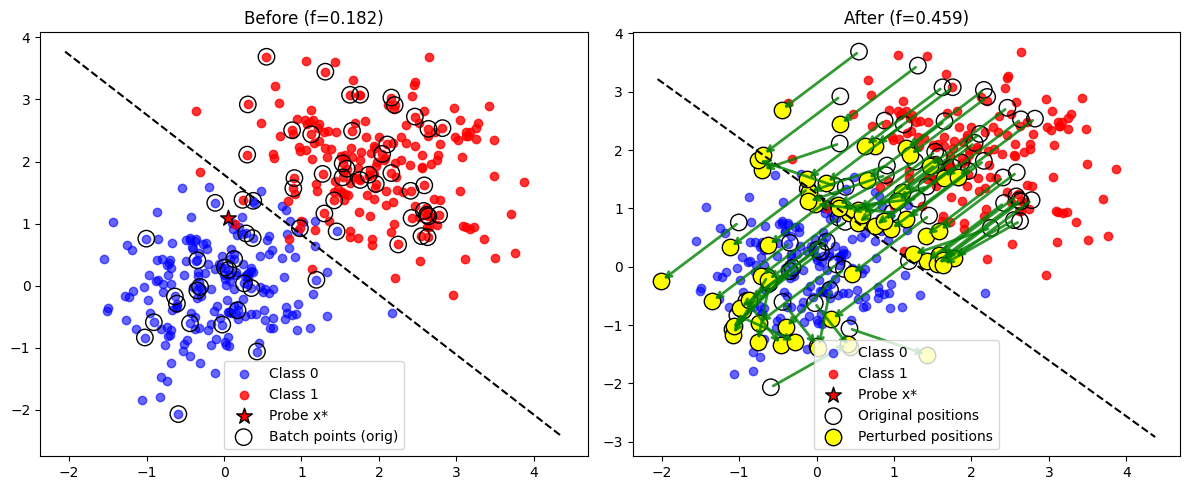

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def grad_f_logprob(x_star, y_star, w, b):
    p_star = sigmoid(x_star @ w + b)
    return (y_star - p_star) * np.append(x_star, 1.0)  # (D+1,)

# Cross-Jacobian J = ∇_x ∇_θ ℓ for logistic regression
def cross_jacobian_x_theta(x, y_label, w, b):
    p = sigmoid(w @ x + b)
    D = x.shape[0]
    top = (p - y_label) * np.eye(D) + (p*(1-p)) * np.outer(x, w)  # (D×D)
    bottom = (p*(1-p)) * w.reshape(1, -1)                          # (1×D)
    return np.vstack([top, bottom])                                # ((D+1)×D)

# Projection operators
def proj_linf(x0, x_candidate, eps):
    return np.clip(x_candidate, x0 - eps, x0 + eps)
def proj_l2(x0, x_candidate, eps):
    d = x_candidate - x0
    n = np.linalg.norm(d, 2)
    if n <= eps or n == 0:
        return x_candidate
    return x0 + d * (eps / n)

# Quick mini-batch refit (same regime as above)
def train_minibatch(X, y, lr=0.05, epochs=150, B=4, rng=rng):
    w = rng.normal(scale=0.1, size=X.shape[1])
    b = 0.0
    N = X.shape[0]
    for ep in range(epochs):
        idx = rng.permutation(N)
        X_ep = X[idx]; y_ep = y[idx]
        for start in range(0, N, B):
            end = min(start+B, N)
            Xb = X_ep[start:end]; yb = y_ep[start:end]
            Bb = Xb.shape[0]
            z = Xb @ w + b
            y_hat = sigmoid(z)
            diff = (y_hat - yb)
            grad_w = (Xb.T @ diff) / Bb
            grad_b = np.mean(diff)
            w -= lr * grad_w
            b -= lr * grad_b
    return w, b

# ----------------------------
# Choose a concrete mini-batch S (size B=4) to perturb
# Strategy: take the next contiguous 4 examples after a fresh shuffle.
# You can swap this for any batch selection scheme you like.
# ----------------------------
B = B
perm2 = rng.permutation(N)
S_idx = perm2[:B]
print("Batch indices S =", S_idx.tolist())

# ----------------------------
# PGD settings (per-example L∞ or L2 budget)
# ----------------------------
EPSILON = 1.0      # norm radius (increased for visibility)
ALPHA   = 0.15     # step size (increased for faster convergence)
P_NORM  = "inf"    # "inf" or "2"
N_STEPS = int(np.ceil(EPSILON / ALPHA)) if P_NORM=="inf" else 15

# ----------------------------
# Compute optimizer-aware directions G_j = -(η/B) J_j^T ∇_θ f
# ----------------------------
eta = lr   # learning rate used in training loop
g_f = grad_f_logprob(x_star, y_star, w, b)         # (D+1,)
theta_t = np.append(w, b)

X0_batch = X[S_idx].copy()
y_batch = y[S_idx].copy()
X_adv = X0_batch.copy()

for step in range(N_STEPS):
    # (optionally re-evaluate g_f each inner step; usually small change, skip for speed)
    # g_f = grad_f_logprob(x_star, y_star, w, b)

    for j_local, j in enumerate(S_idx):
        xj0 = X0_batch[j_local]
        yj  = int(y_batch[j_local])

        # J_j at current params
        Jj = cross_jacobian_x_theta(X_adv[j_local], yj, w, b)  # ((D+1)×D)

        # G_j = -(η/B) * J_j^T * ∇_θ f
        Gj = - (eta / B) * (Jj.T @ g_f)                        # (D,)

        # PGD step + projection
        if P_NORM == "inf":
            step_vec = ALPHA * np.sign(Gj)
            cand = X_adv[j_local] + step_vec
            X_adv[j_local] = proj_linf(xj0, cand, EPSILON)
        else:
            gnorm = np.linalg.norm(Gj, 2) + 1e-12
            step_vec = ALPHA * (Gj / gnorm)
            cand = X_adv[j_local] + step_vec
            X_adv[j_local] = proj_l2(xj0, cand, EPSILON)

# Replace the B points with their crafted versions
X_pert = X.copy()
X_pert[S_idx] = X_adv

# ----------------------------
# Evaluate f(θ) before/after retraining (mini-batch regime)
# ----------------------------
p_star_before = sigmoid(x_star @ w + b)
f_before = p_star_before if y_star==1 else (1 - p_star_before)

w_new, b_new = train_minibatch(X_pert, y, lr=lr, epochs=200, B=B, rng=rng)

p_star_after = sigmoid(x_star @ w_new + b_new)
f_after = p_star_after if y_star==1 else (1 - p_star_after)

print(f"Probe (x*, y*) = {x_star}, {y_star}")
print(f"f(θ) before = {f_before:.6f} ; after = {f_after:.6f} ; Δ = {f_after - f_before:+.6f}")

# ----------------------------
# Visualize the perturbed batch and decision boundary shift
# ----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Before
ax[0].scatter(X[y==0,0], X[y==0,1], color="blue", alpha=0.6, label="Class 0")
ax[0].scatter(X[y==1,0], X[y==1,1], color="red",  alpha=0.8, label="Class 1")
ax[0].scatter(*x_star, marker="*", s=140, edgecolor="k",
              color=("red" if y_star==1 else "blue"), label="Probe x*")
ax[0].scatter(X0_batch[:,0], X0_batch[:,1], s=140, edgecolor="k",
              facecolors="none", label="Batch points (orig)")
xs = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300)
if abs(w[1]) < 1e-8:
    xb = -b / w[0] if abs(w[0]) > 1e-8 else 0.0
    ax[0].axvline(x=xb, color="k", linestyle="--")
else:
    ys_line = -(w[0]*xs + b) / w[1]
    ax[0].plot(xs, ys_line, "k--")
ax[0].set_title(f"Before (f={f_before:.3f})"); ax[0].legend()

# After - with arrows showing movement
ax[1].scatter(X_pert[y==0,0], X_pert[y==0,1], color="blue", alpha=0.6, label="Class 0")
ax[1].scatter(X_pert[y==1,0], X_pert[y==1,1], color="red",  alpha=0.8, label="Class 1")
ax[1].scatter(*x_star, marker="*", s=140, edgecolor="k",
              color=("red" if y_star==1 else "blue"), label="Probe x*")

# Show original positions with hollow circles
ax[1].scatter(X0_batch[:,0], X0_batch[:,1], s=140, edgecolor="k",
              facecolors="none", label="Original positions")

# Show perturbed positions with filled yellow circles
ax[1].scatter(X_adv[:,0], X_adv[:,1], s=140, edgecolor="k",
              color="yellow", label="Perturbed positions")

# Add arrows showing movement from original to perturbed positions
for i in range(len(X0_batch)):
    ax[1].annotate('', xy=X_adv[i], xytext=X0_batch[i],
                   arrowprops=dict(arrowstyle='->', color='green', lw=2, alpha=0.8))

# Add decision boundary
if abs(w_new[1]) < 1e-8:
    xb = -b_new / w_new[0] if abs(w_new[0]) > 1e-8 else 0.0
    ax[1].axvline(x=xb, color="k", linestyle="--")
else:
    ys_line = -(w_new[0]*xs + b_new) / w_new[1]
    ax[1].plot(xs, ys_line, "k--")

ax[1].set_title(f"After (f={f_after:.3f})"); ax[1].legend()

plt.tight_layout()
plt.show()

# Keep updated params/data if you want to continue
w, b = w_new, b_new
X = X_pert